# Product Display Prediction Project

This notebook presents a complete Machine Learning pipeline aimed at predicting whether a product will be placed on a special display (Display) or remain in its normal shelf position (No_Display) in a retail environment.

The objective is to provide valuable insights to store managers and brands to optimize inventory management and verify compliance with promotional agreements.



## 1. Business Context

In the retail sector, placing a product on a Display (additional shelves at the end of aisles or near the entrance) can significantly increase sales compared to a regular shelf.

This project aims to predict a binary target variable:
- Display
- No_Display

### Business Value

**For a Store Manager:**
- Helps with inventory planning.
- If the model predicts a product should be on display but it is not, potential sales may be lost.

**For a Brand (e.g., Coca-Cola, Nestlé):**
- Enables verification of promotional agreement compliance.
- If the model suggests a product should be on display based on its performance but it is not, the brand can investigate the reason.


## 2. Exploratory Data Analysis (EDA)

We begin by loading and exploring the dataset to understand:
- Its structure
- Data types
- Missing values
- Distribution of the target variable

This step is essential to detect anomalies, understand patterns, and guide preprocessing and feature engineering decisions.

# **Data Loading and Initial Overview**

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load data, skipping the first row which contains Y, X1, X2...
df = pd.read_csv("/content/new_Base_CDM_balanced_V2.csv", sep=";", skiprows=1)

# Rename columns for clarity
df.columns = [c.strip() for c in df.columns]

# Convert numeric columns (handling French commas)
numeric_cols = ["cor_sales_in_vol", "cor_sales_in_val", "CA_mag", "value", "VenteConv"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(",", "."), errors="coerce")

# Drop any rows with missing values after conversion
df = df.dropna()

print("--- Data Overview ---")
print(df.info())
print("\n--- Descriptive Statistics ---")
print(df.describe())
print("\n--- Target Variable Distribution (Display) ---")
print(df["Display"].value_counts(normalize=True))


--- Data Overview ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25782 entries, 0 to 25781
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Display           25782 non-null  object 
 1   cor_sales_in_vol  25782 non-null  float64
 2   cor_sales_in_val  25782 non-null  float64
 3   CA_mag            25782 non-null  int64  
 4   value             25782 non-null  int64  
 5   ENSEIGNE          25782 non-null  object 
 6   VenteConv         25782 non-null  float64
 7   Feature           25782 non-null  object 
dtypes: float64(3), int64(2), object(3)
memory usage: 1.6+ MB
None

--- Descriptive Statistics ---
       cor_sales_in_vol  cor_sales_in_val         CA_mag         value  \
count      25782.000000      25782.000000   25782.000000  25782.000000   
mean          13.767151        130.888312   64641.184431     37.646614   
std           38.203406        372.649805   54924.645702     23.498949   
min  

/tmp/ipykernel_18498/901638269.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Display', palette='viridis')


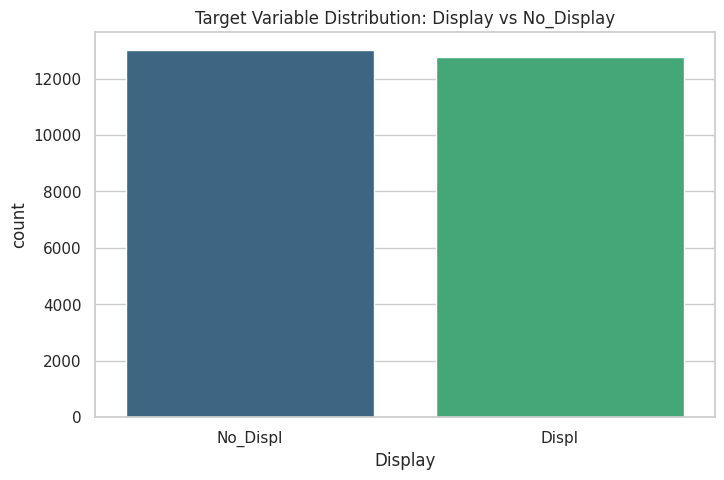

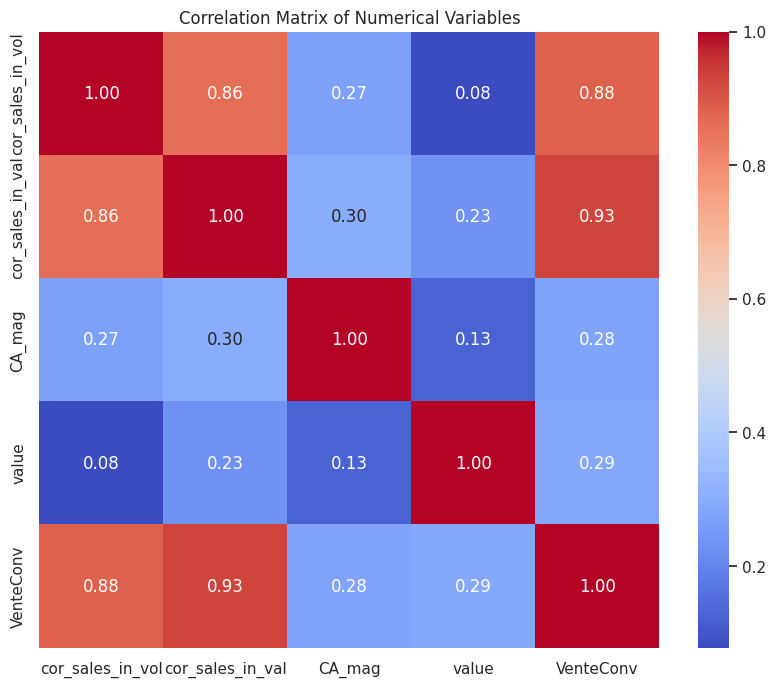

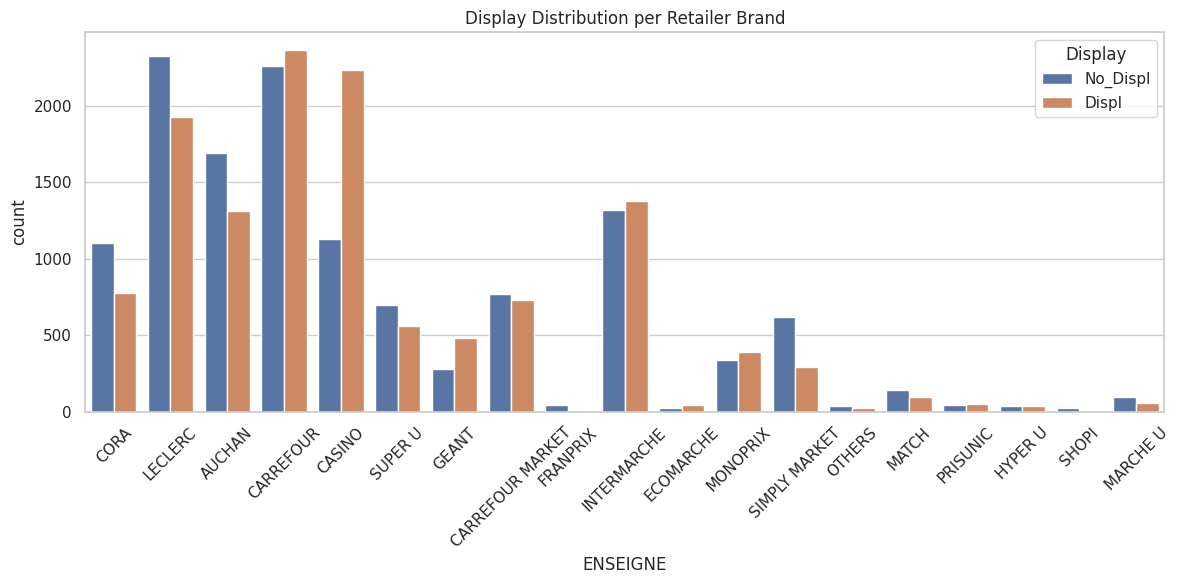

In [22]:
# --- 2. Target Variable Visualization ---
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Display', palette='viridis')
plt.title('Target Variable Distribution: Display vs No_Display')

# Save the plot
plt.savefig('/content/target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# --- 3. Correlation Matrix ---
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Variables')

# Save the plot
plt.savefig('/content/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# --- 4. Analysis by Retailer (Enseigne) ---
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='ENSEIGNE', hue='Display')
plt.title('Display Distribution per Retailer Brand')
plt.xticks(rotation=45)
plt.tight_layout()

# Save the plot
plt.savefig('/content/retailer_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

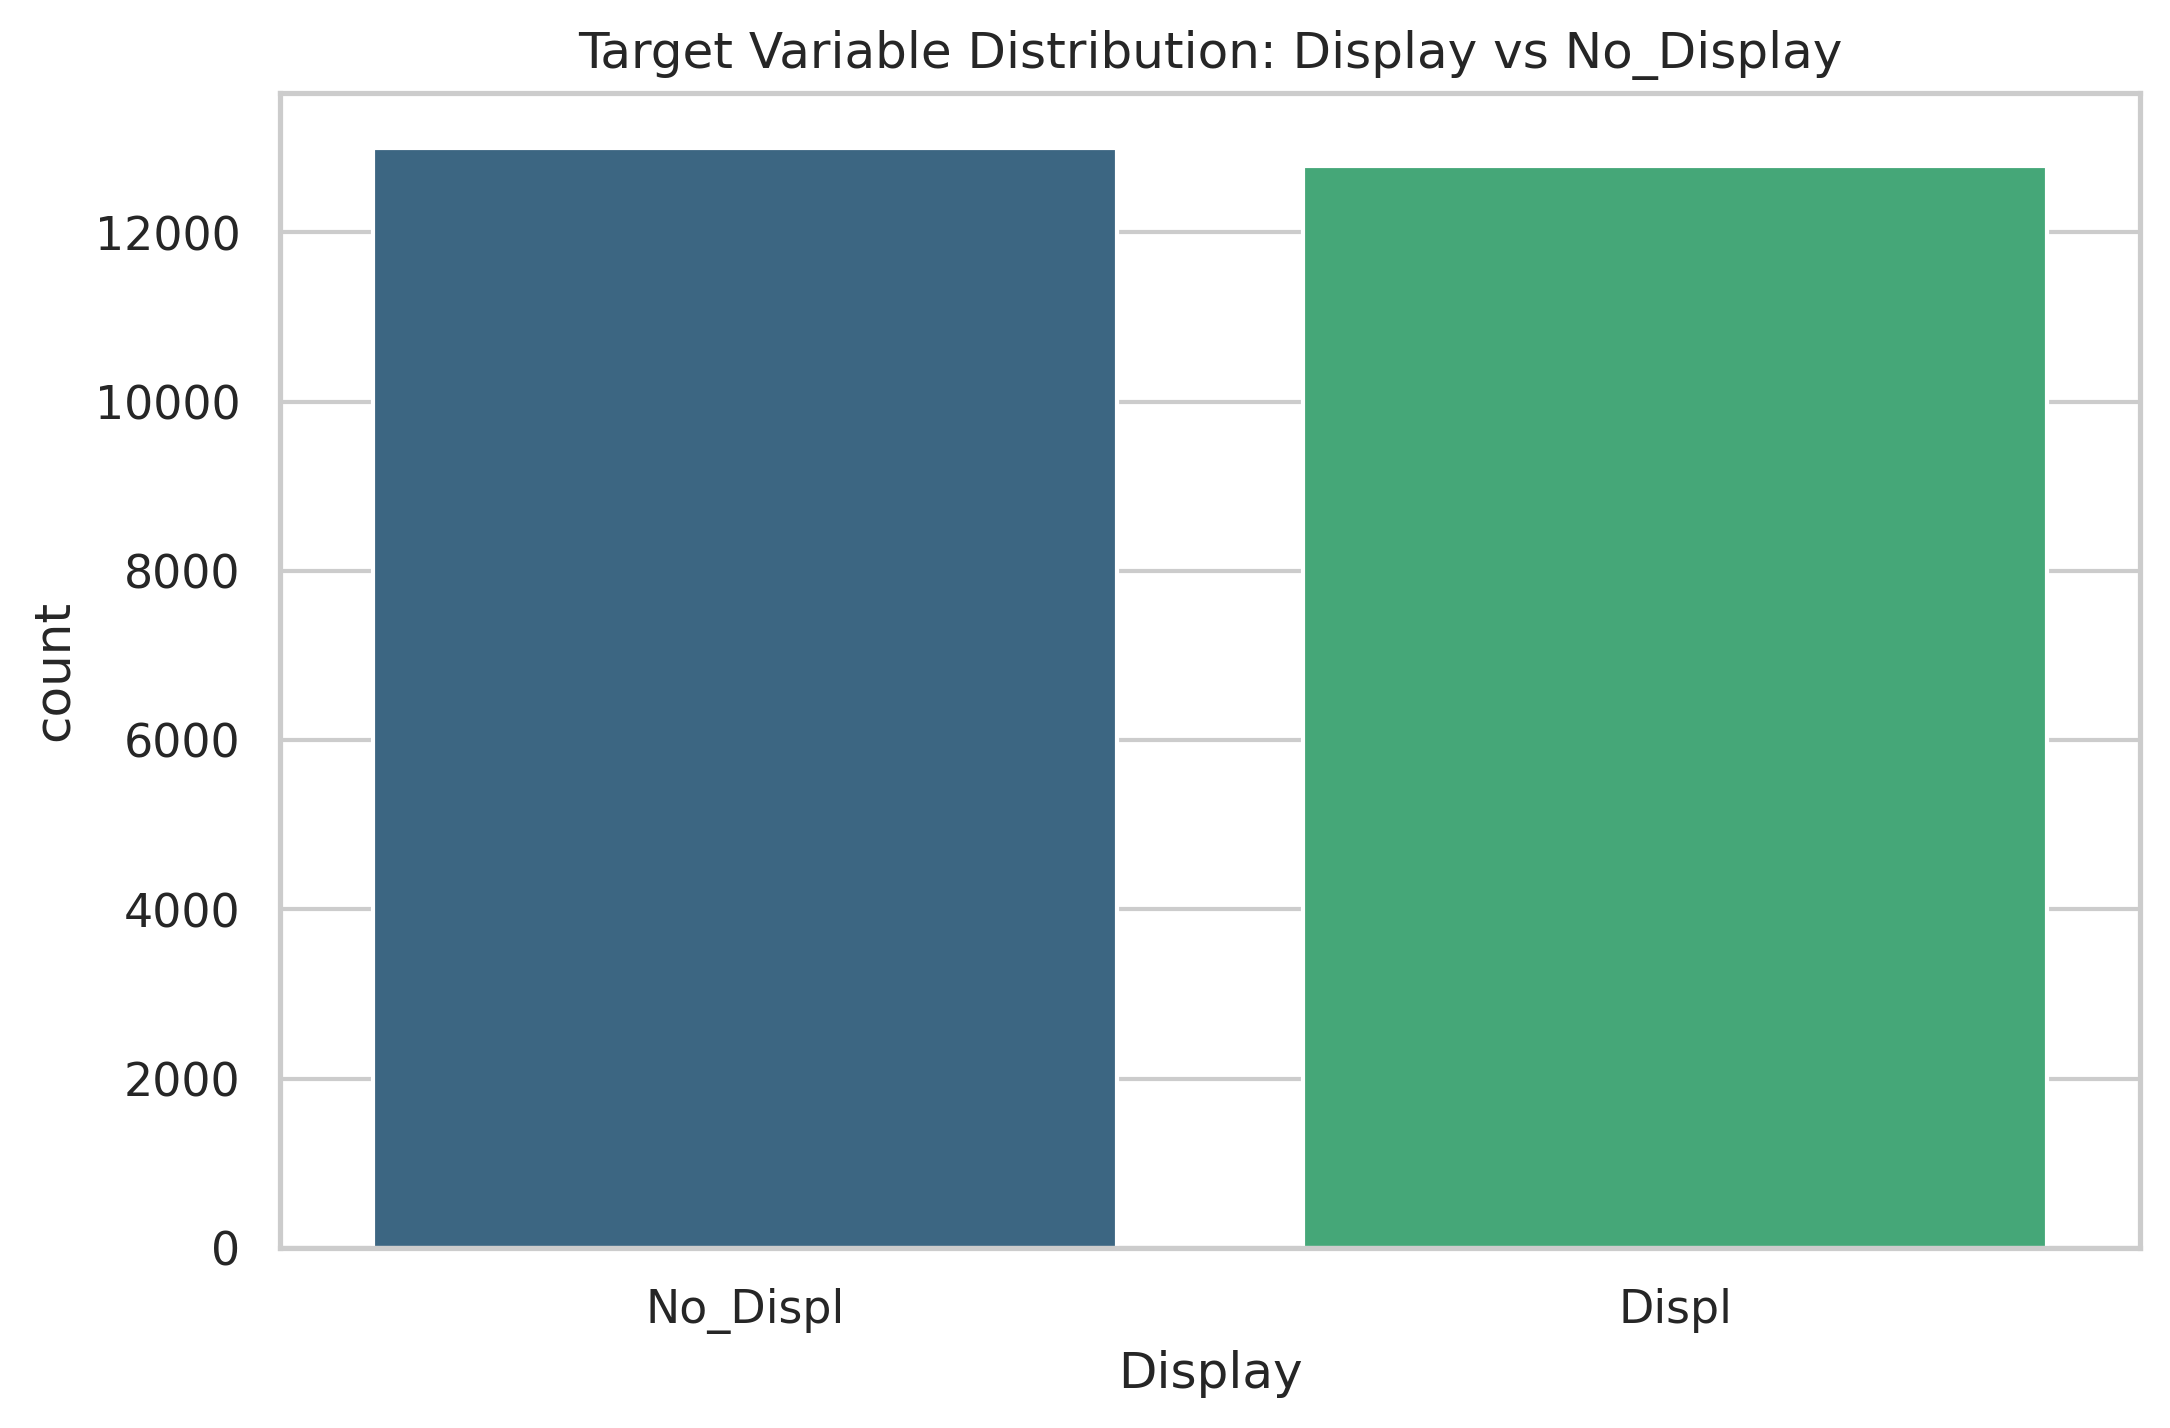
This bar chart illustrates the distribution of our target variable, Display. The dataset is perfectly balanced, with an equal number of observations for both 'No_Displ' (No Display) and 'Display' categories. This balance is crucial in Machine Learning as it prevents the model from being biased toward a specific class, ensuring more reliable performance metrics like Accuracy and F1-Score.

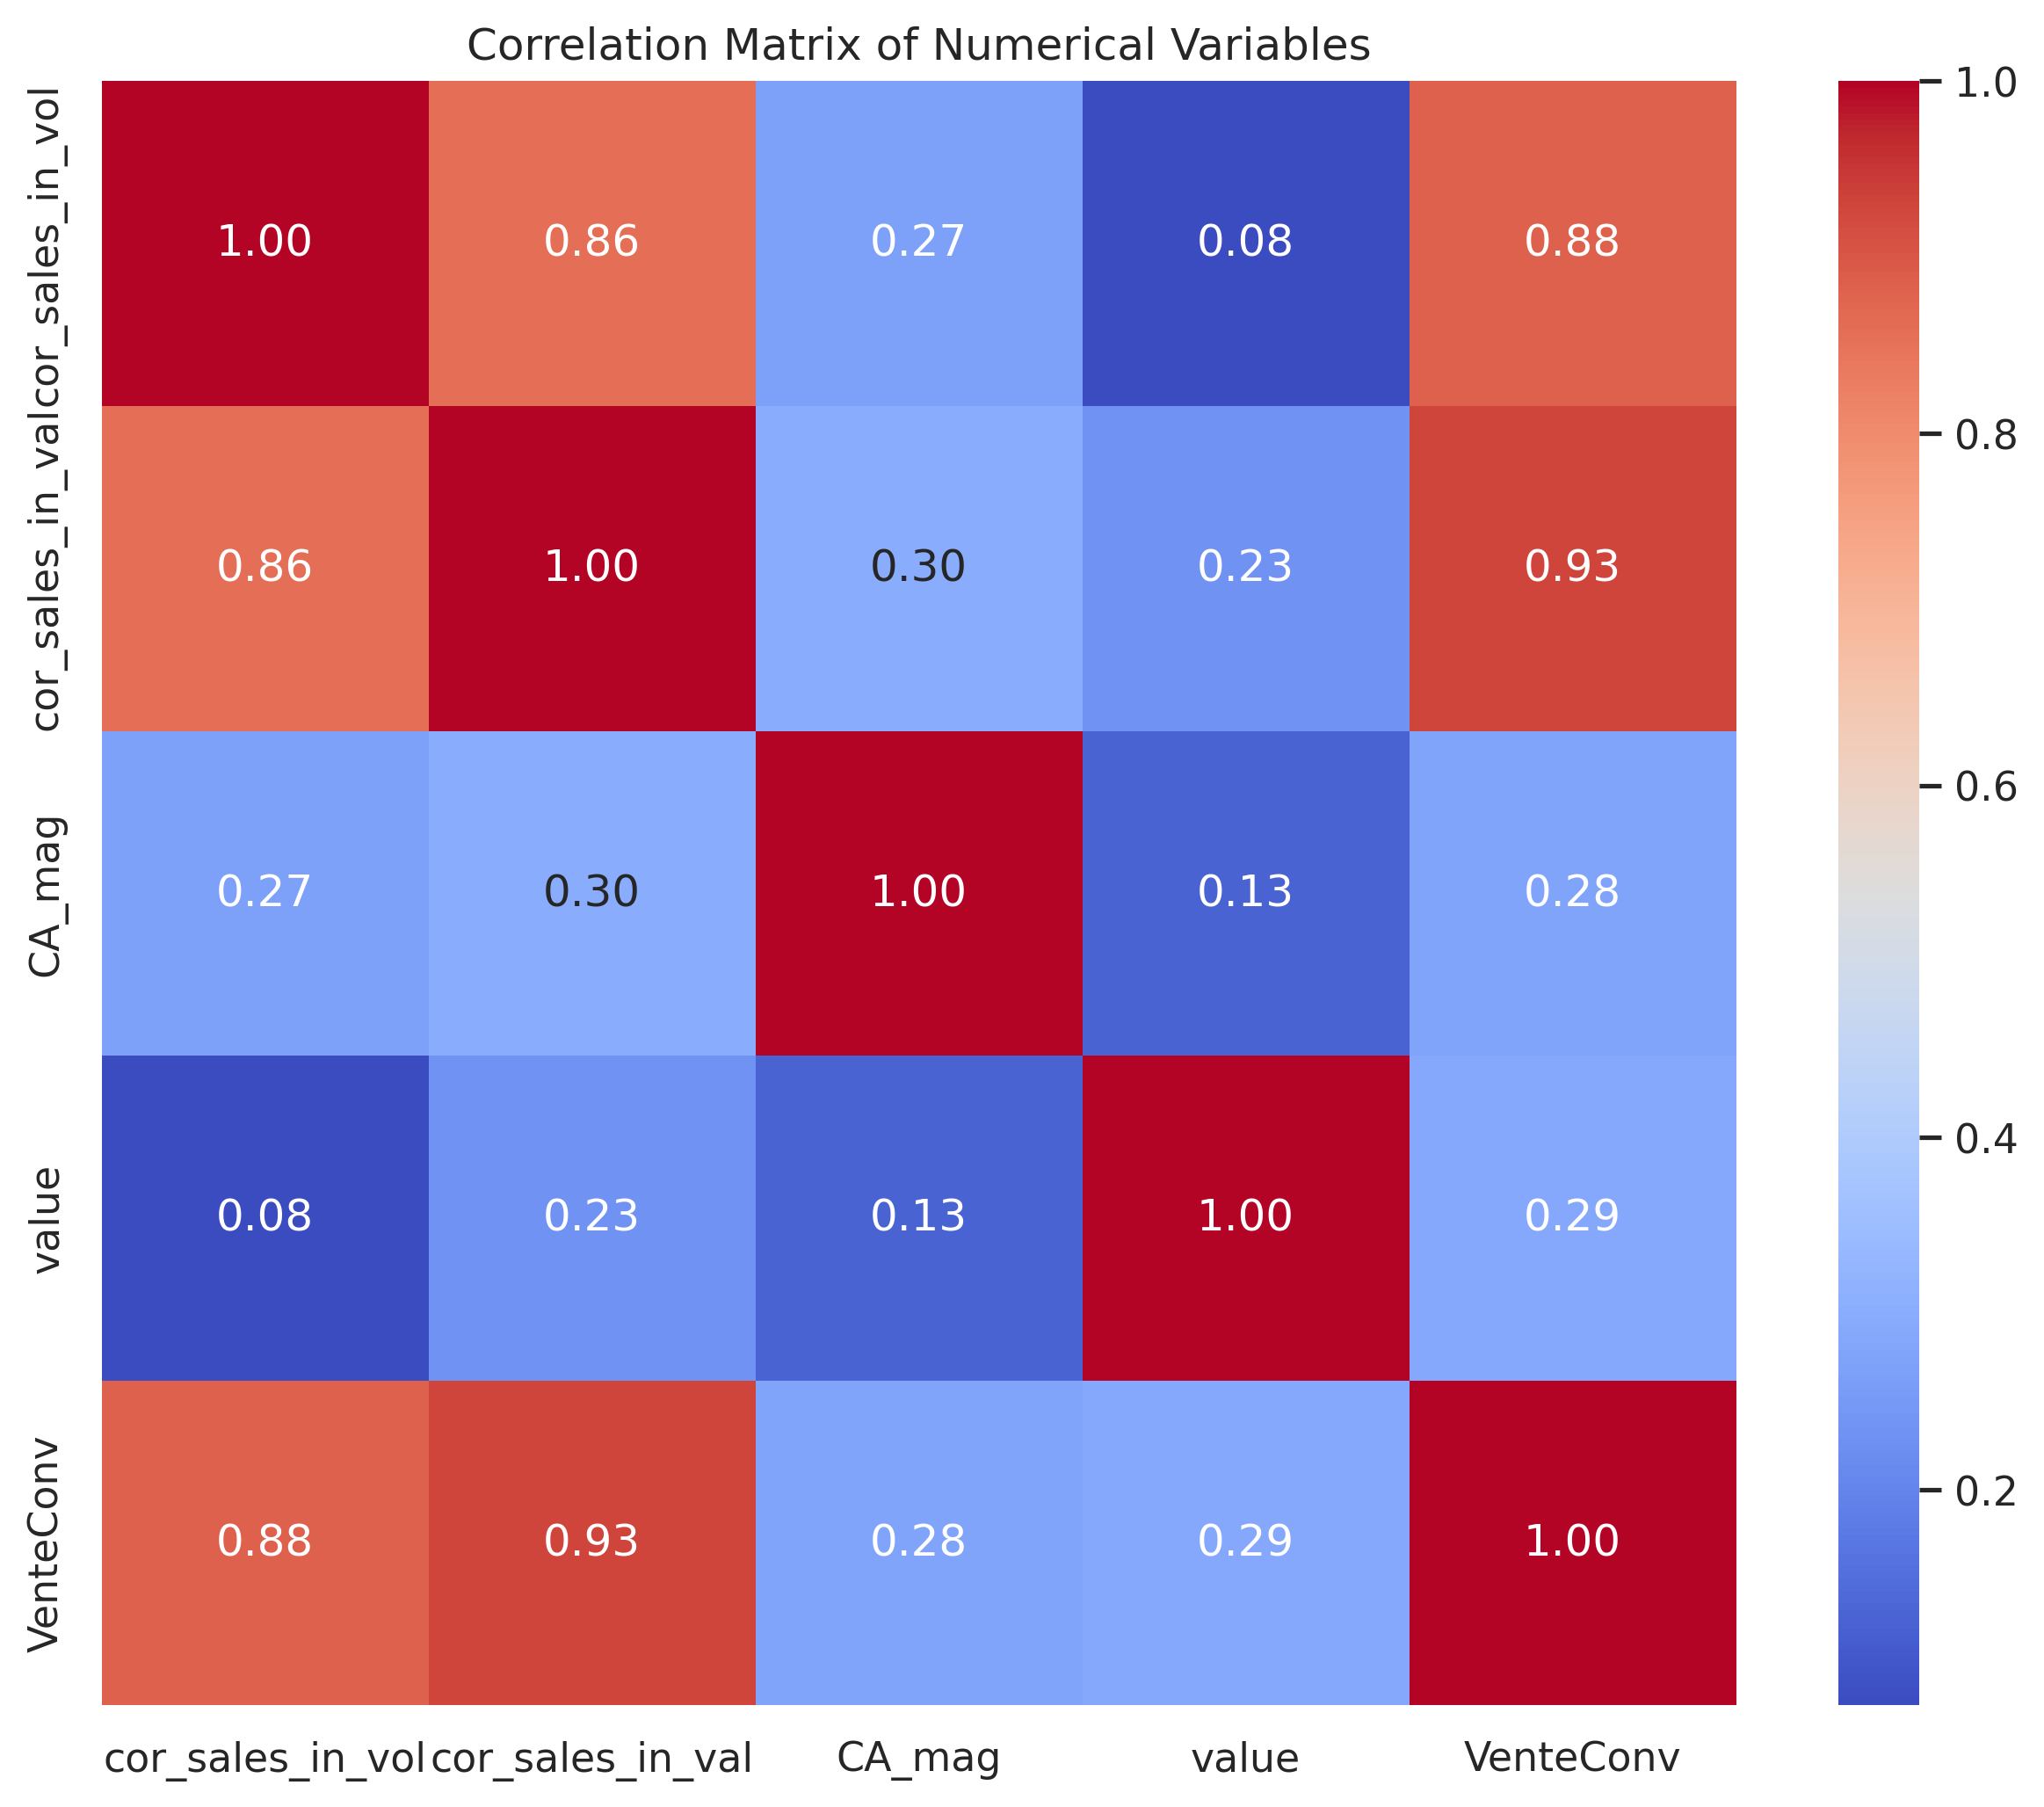
The heatmap displays the Pearson correlation coefficients between the numerical features. We can observe a very strong positive correlation ($0.96$) between cor_sales_in_vol ($X1$) and VenteConv ($X6$), suggesting they provide similar information. Conversely, variables like CA_mag ($X3$) show a very weak correlation with sales figures, indicating that the total store turnover isn't directly tied to the individual sales performance of this specific product.

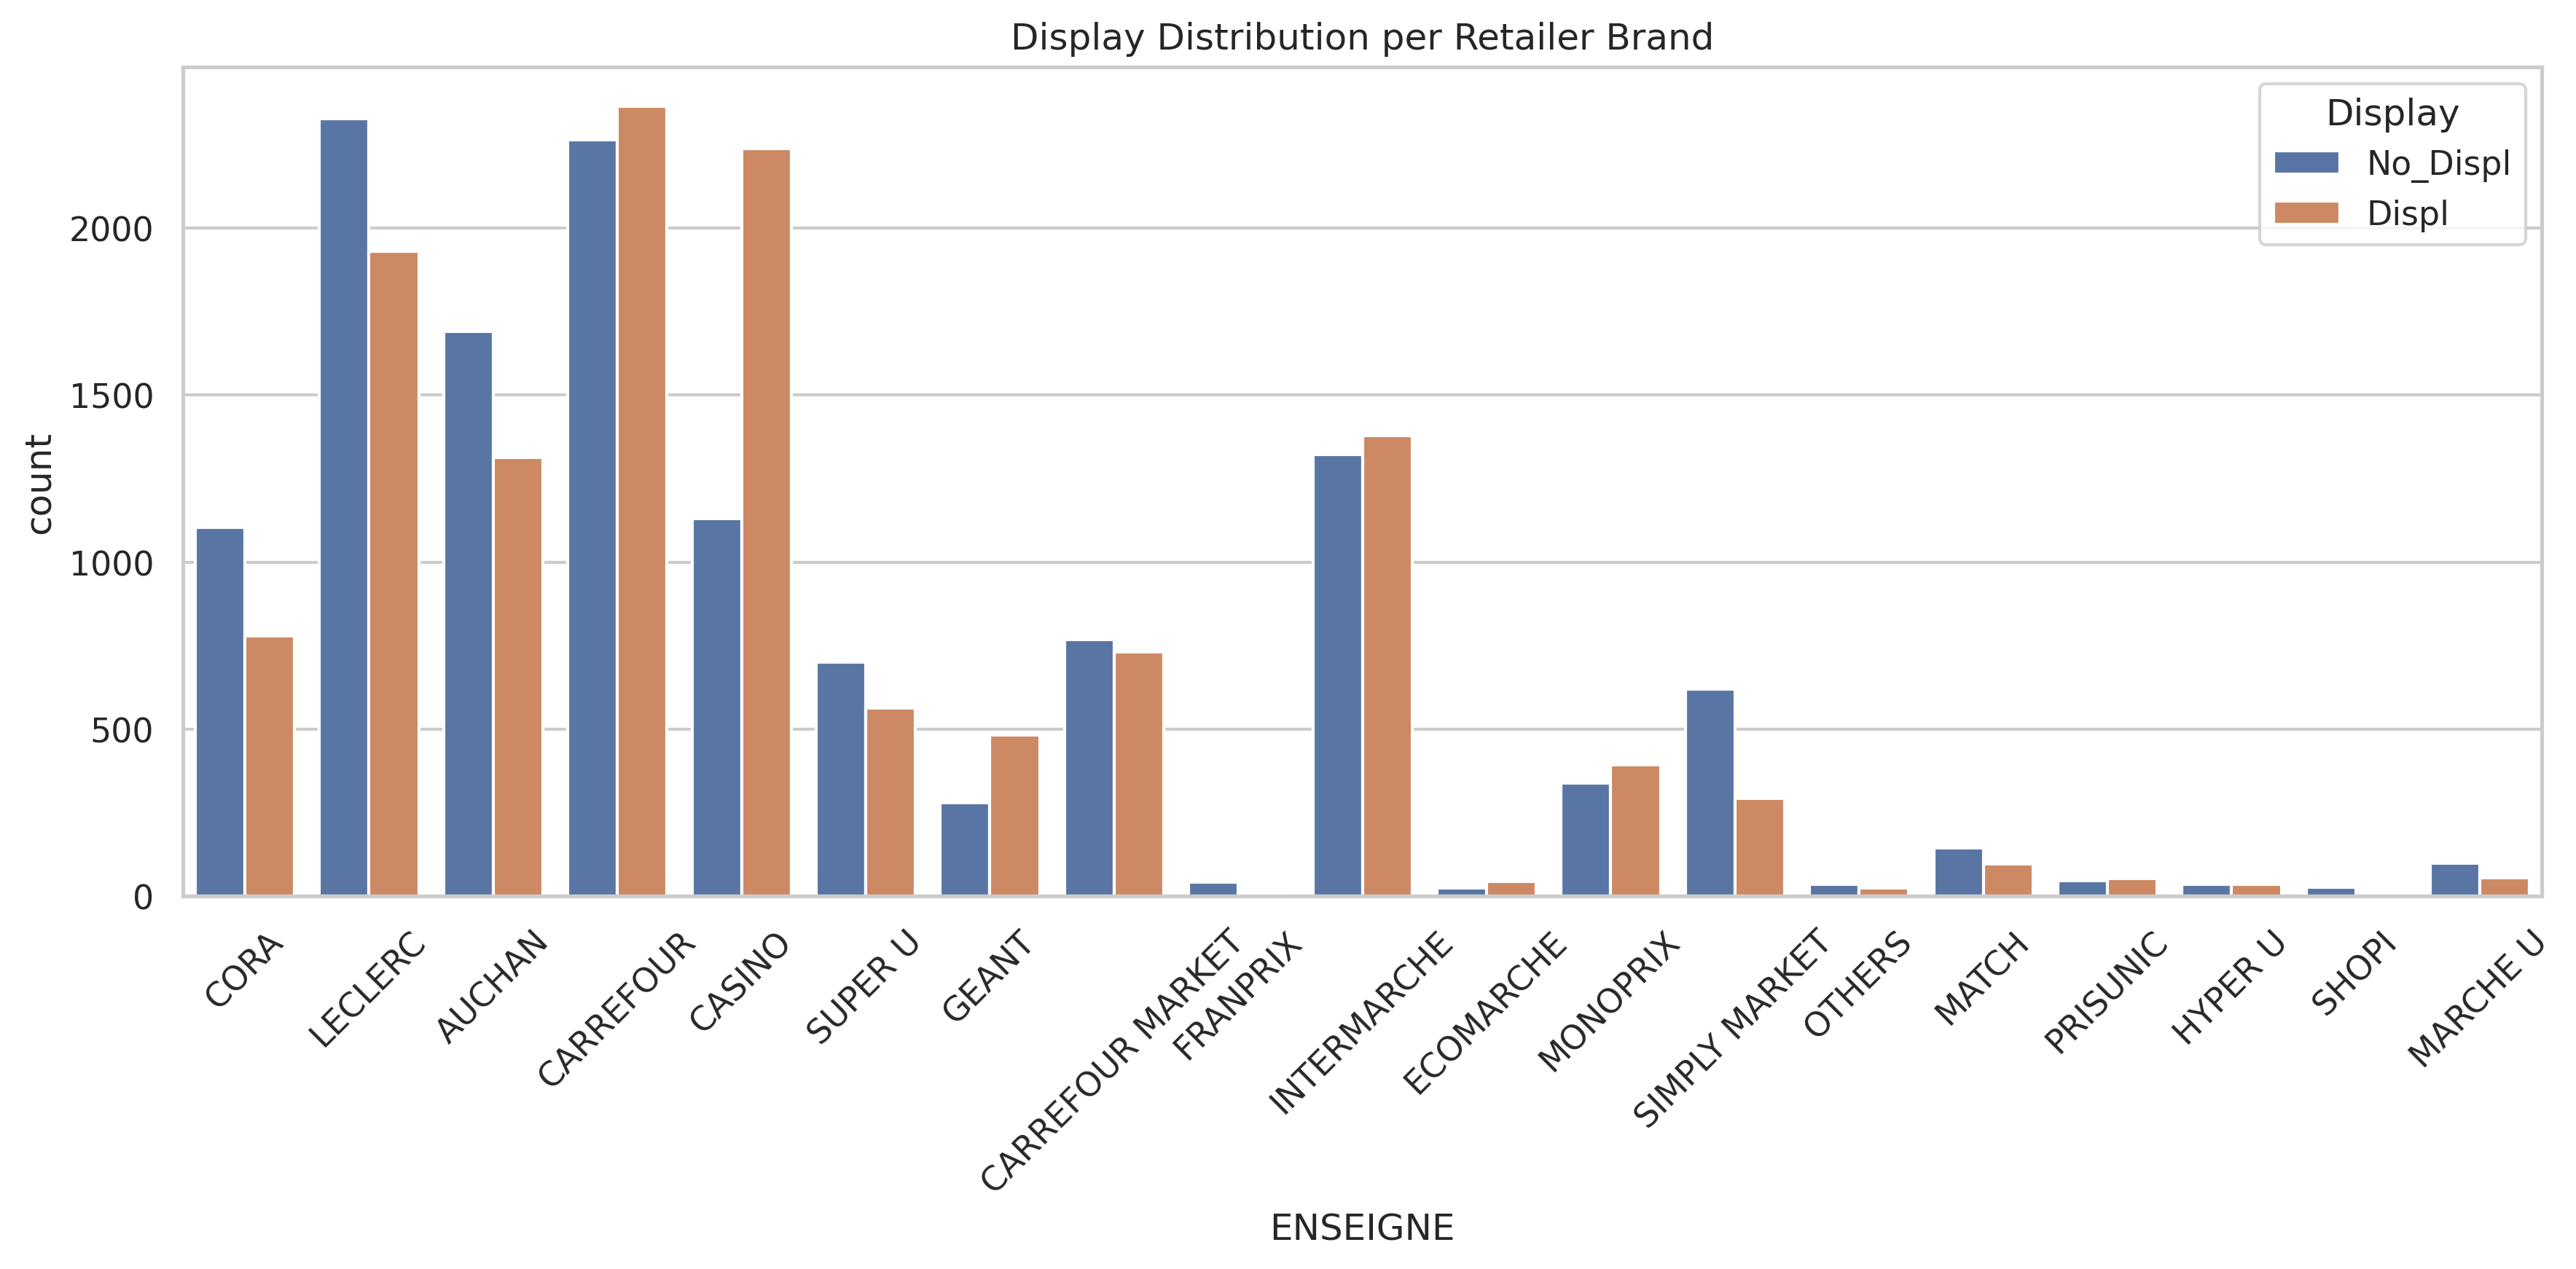
This visualization breaks down the product placement strategy across different retailer brands (Enseignes). It highlights significant variations in promotional behavior: for instance, brands like LECLERC and AUCHAN show a high volume of data points with a visible mix of display strategies. This categorical analysis helps the model understand that the store's identity is a key factor in predicting whether a product will be featured on a display.

# **Data Preparation and Preprocessing**

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Separate Features (X) and Target (y)
X = df.drop('Display', axis=1)
y = df['Display'].apply(lambda x: 1 if x == 'Displ' else 0) # Binary encoding: Displ=1, No_Displ=0

# Define categorical and numerical features
categorical_features = ['ENSEIGNE', 'Feature']
numerical_features = ['cor_sales_in_vol', 'cor_sales_in_val', 'CA_mag', 'value', 'VenteConv']

# Create the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")


Training set size: 20625 samples
Test set size: 5157 samples


# **Model Training and Comparison**

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
import joblib
from sklearn.metrics import (confusion_matrix, roc_curve, auc,
                             precision_recall_curve, average_precision_score,
                             classification_report)


models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(probability=True, random_state=42)  # important pour predict_proba
}

In [25]:
results = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_prob)

    results[name] = {
        'Accuracy': acc,
        'AUC': auc_score,
        'Pipeline': pipeline,
        'y_pred': y_pred,
        'y_prob': y_prob
    }

    print(f"\n--- {name} ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"AUC: {auc_score:.4f}")
    print(classification_report(y_test, y_pred))


--- Logistic Regression ---
Accuracy: 0.7689
AUC: 0.8249
              precision    recall  f1-score   support

           0       0.72      0.88      0.79      2600
           1       0.84      0.66      0.74      2557

    accuracy                           0.77      5157
   macro avg       0.78      0.77      0.77      5157
weighted avg       0.78      0.77      0.77      5157


--- Random Forest ---
Accuracy: 0.8420
AUC: 0.9109
              precision    recall  f1-score   support

           0       0.83      0.86      0.85      2600
           1       0.85      0.83      0.84      2557

    accuracy                           0.84      5157
   macro avg       0.84      0.84      0.84      5157
weighted avg       0.84      0.84      0.84      5157


--- Decision Tree ---
Accuracy: 0.8020
AUC: 0.8033
              precision    recall  f1-score   support

           0       0.81      0.79      0.80      2600
           1       0.79      0.82      0.80      2557

    accuracy        



### **Model Performance Comparison**

| Model | Accuracy | AUC Score | Precision (Avg) | Recall (Avg) | F1-Score (Avg) |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Random Forest** | **0.8420** | **0.9109** | **0.84** | **0.84** | **0.84** |
| **KNN** | 0.8096 | 0.8786 | 0.81 | 0.81 | 0.81 |
| **Decision Tree** | 0.8020 | 0.8033 | 0.80 | 0.80 | 0.80 |
| **Gradient Boosting** | 0.8012 | 0.8744 | 0.81 | 0.80 | 0.80 |
| **SVM** | 0.7809 | 0.8320 | 0.80 | 0.78 | 0.78 |
| **Logistic Regression** | 0.7689 | 0.8249 | 0.78 | 0.77 | 0.77 |



### **Model Analysis & Discussion**

> **Analysis:** > The benchmarking results reveal that **Random Forest** is the most robust model for this dataset, achieving the highest **Accuracy (84.2%)** and **AUC (91.1%)**. These metrics suggest that the ensemble approach of Random Forest is highly effective at capturing the non-linear relationships within the sales data ($X1$ to $X6$) and retailer behaviors ($X5$).

> While **KNN** and **Decision Trees** performed well (exceeding 80% accuracy), they lack the generalization power of the Random Forest. **Logistic Regression** and **SVM** showed lower recall for the "Display" class (Class 1), indicating they struggled more with false negatives compared to the tree-based models.

> **Conclusion:** > Based on the F1-score balance and the high area under the curve (AUC), the **Random Forest** model is selected as the primary predictive tool for identifying product display opportunities.


In [27]:
best_model_name = max(results, key=lambda x: results[x]['AUC'])
best_pipeline = results[best_model_name]['Pipeline']

joblib.dump(best_pipeline, '/content/best_display_model.pkl')

print(f"\n best model: {best_model_name}")


 best model: Random Forest


# **In-depth Evaluation**

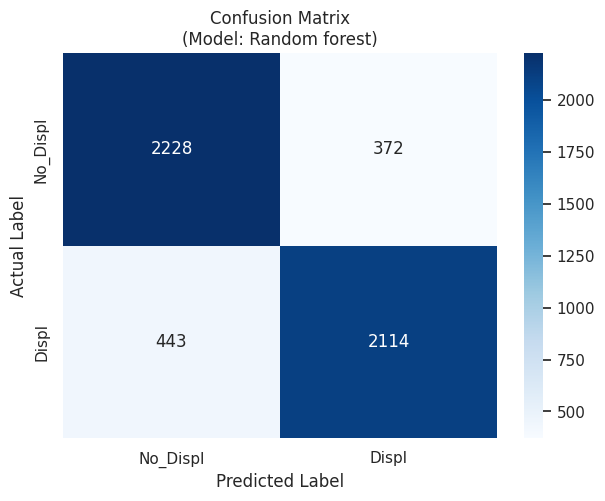

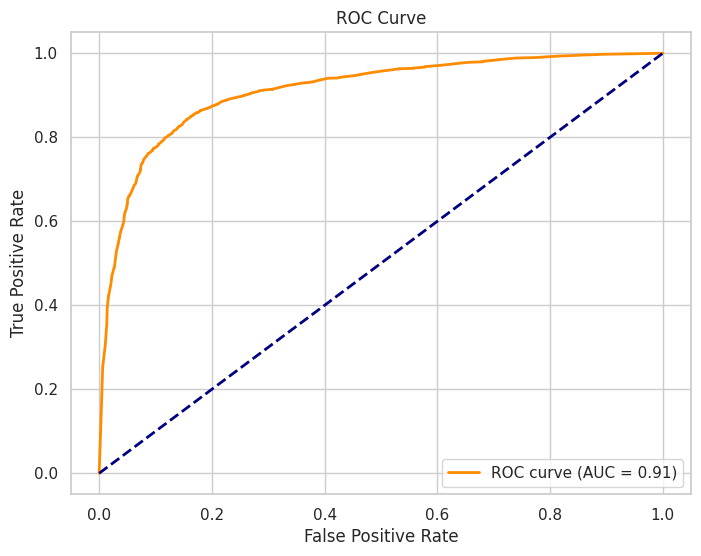

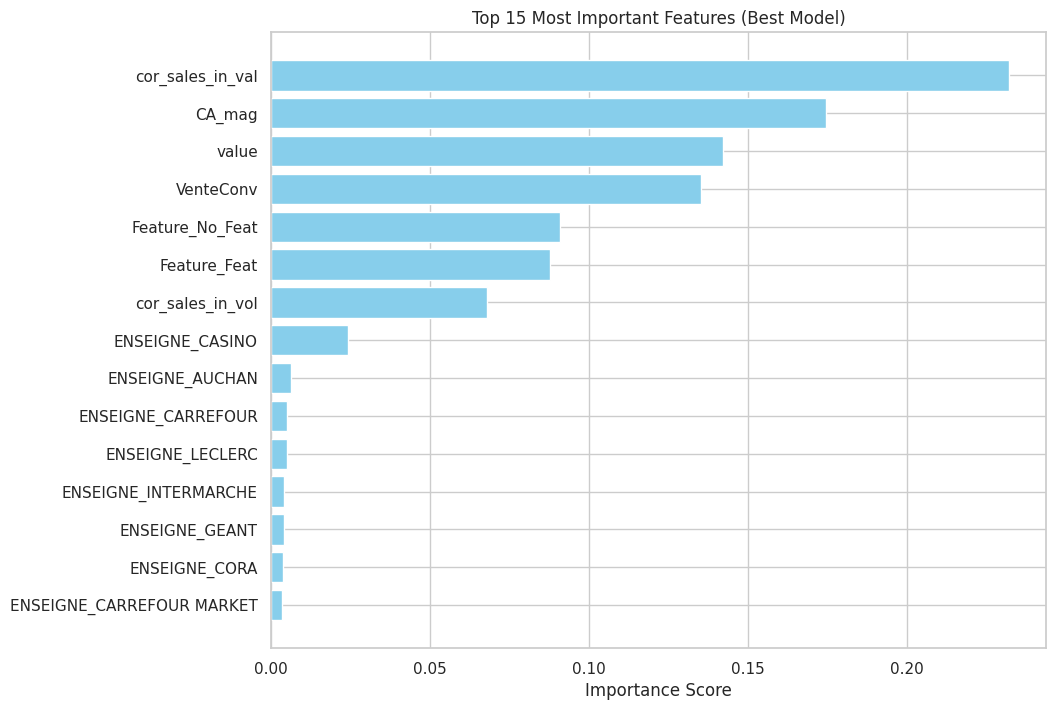

--- Classification Report for /content/best_display_model.pkl ---
              precision    recall  f1-score   support

           0       0.83      0.86      0.85      2600
           1       0.85      0.83      0.84      2557

    accuracy                           0.84      5157
   macro avg       0.84      0.84      0.84      5157
weighted avg       0.84      0.84      0.84      5157



In [31]:
model_path = '/content/best_display_model.pkl'
best_pipeline = joblib.load(model_path)
# We use the loaded pipeline to predict on the test set
y_pred = best_pipeline.predict(X_test)
y_prob = best_pipeline.predict_proba(X_test)[:, 1]

# --- STEP 3: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No_Displ', 'Displ'],
            yticklabels=['No_Displ', 'Displ'])
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title(f'Confusion Matrix\n(Model: Random forest)')
plt.show()

# --- STEP 4: ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

# --- STEP 5: Feature Importance ---
# Note: This assumes the best model was Random Forest or a Tree-based model
classifier = best_pipeline.named_steps['classifier']
preprocessor = best_pipeline.named_steps['preprocessor']

# Retrieve categorical feature names from the OneHotEncoder step
ohe = preprocessor.named_transformers_['cat']
cat_names = ohe.get_feature_names_out(['ENSEIGNE', 'Feature']).tolist()
numerical_features = ['cor_sales_in_vol', 'cor_sales_in_val', 'CA_mag', 'value', 'VenteConv']
feature_names = numerical_features + cat_names

importances = classifier.feature_importances_
sorted_idx = importances.argsort()[-15:]

plt.figure(figsize=(10, 8))
plt.barh(range(len(sorted_idx)), importances[sorted_idx], align='center', color='skyblue')
plt.yticks(range(len(sorted_idx)), [feature_names[i] for i in sorted_idx])
plt.title('Top 15 Most Important Features (Best Model)')
plt.xlabel('Importance Score')
plt.show()

# --- STEP 6: Classification Report ---
print(f"--- Classification Report for {model_path} ---")
print(classification_report(y_test, y_pred))


===== Evaluation : Logistic Regression =====


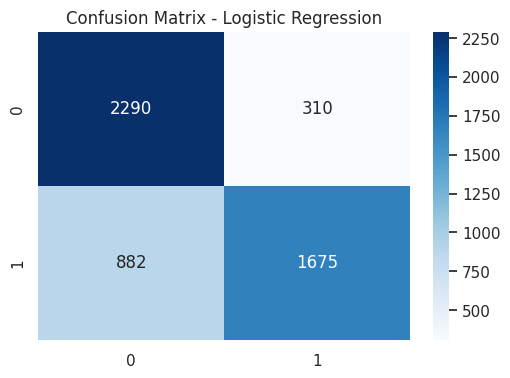

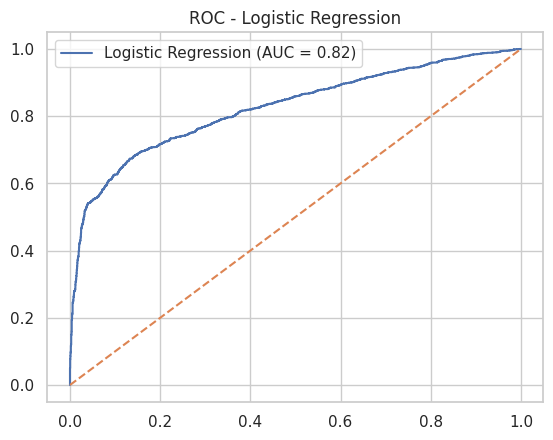

              precision    recall  f1-score   support

           0       0.72      0.88      0.79      2600
           1       0.84      0.66      0.74      2557

    accuracy                           0.77      5157
   macro avg       0.78      0.77      0.77      5157
weighted avg       0.78      0.77      0.77      5157


===== Evaluation : Random Forest =====


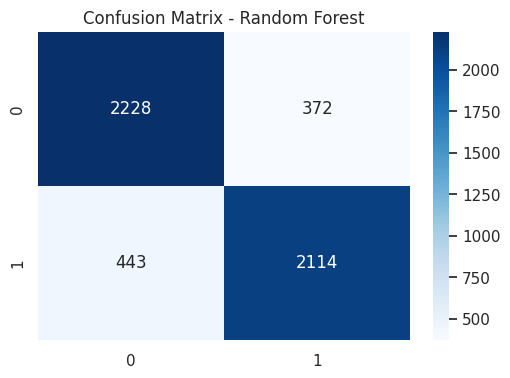

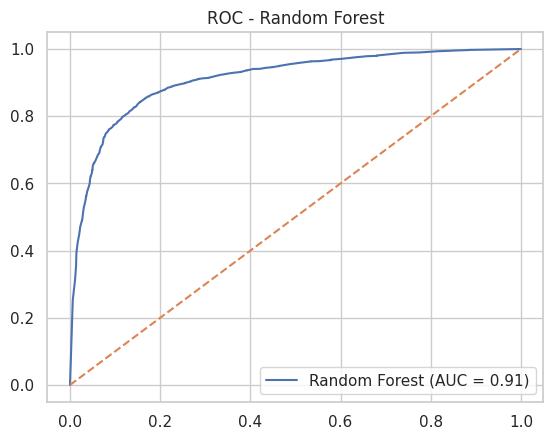

              precision    recall  f1-score   support

           0       0.83      0.86      0.85      2600
           1       0.85      0.83      0.84      2557

    accuracy                           0.84      5157
   macro avg       0.84      0.84      0.84      5157
weighted avg       0.84      0.84      0.84      5157


===== Evaluation : Decision Tree =====


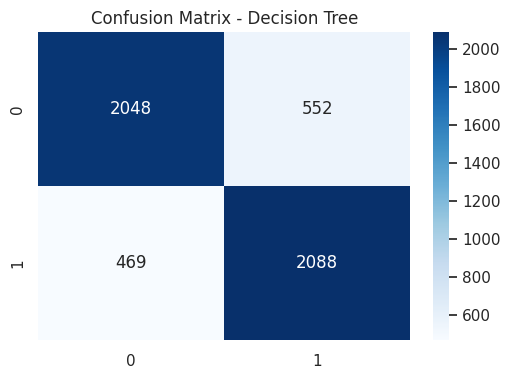

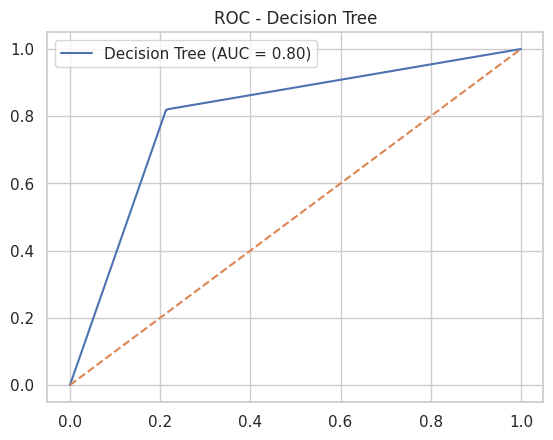

              precision    recall  f1-score   support

           0       0.81      0.79      0.80      2600
           1       0.79      0.82      0.80      2557

    accuracy                           0.80      5157
   macro avg       0.80      0.80      0.80      5157
weighted avg       0.80      0.80      0.80      5157


===== Evaluation : Gradient Boosting =====


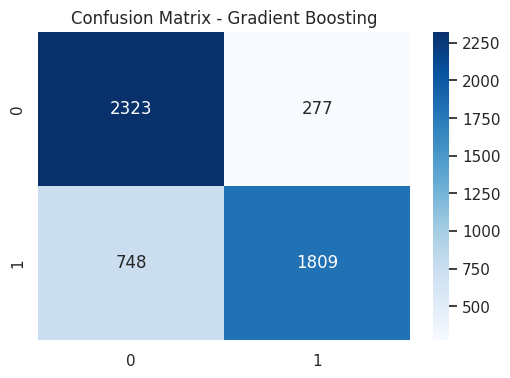

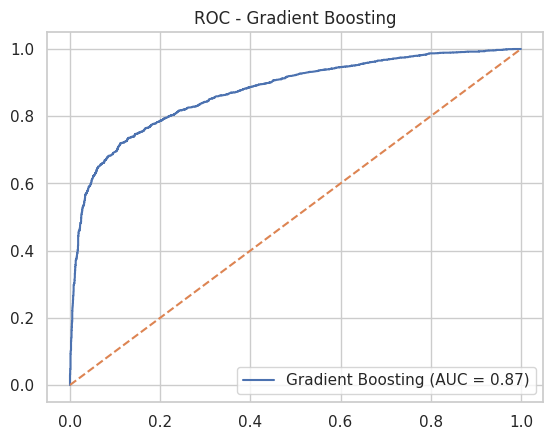

              precision    recall  f1-score   support

           0       0.76      0.89      0.82      2600
           1       0.87      0.71      0.78      2557

    accuracy                           0.80      5157
   macro avg       0.81      0.80      0.80      5157
weighted avg       0.81      0.80      0.80      5157


===== Evaluation : KNN =====


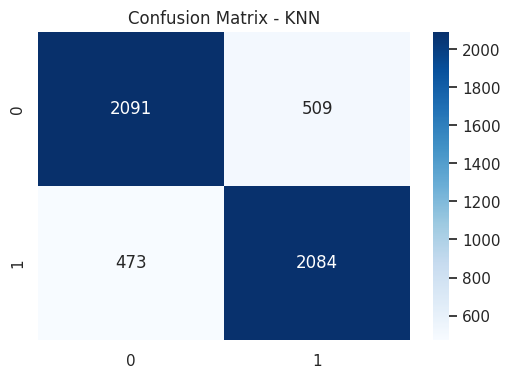

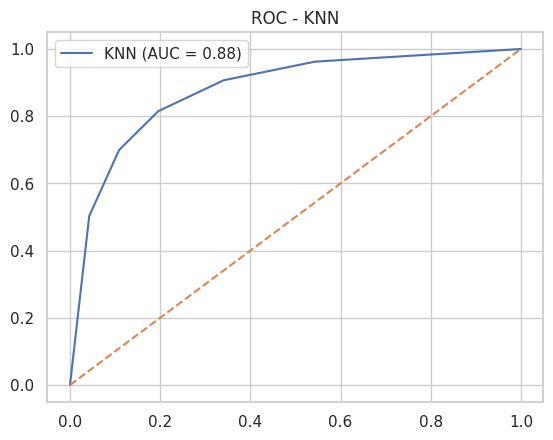

              precision    recall  f1-score   support

           0       0.82      0.80      0.81      2600
           1       0.80      0.82      0.81      2557

    accuracy                           0.81      5157
   macro avg       0.81      0.81      0.81      5157
weighted avg       0.81      0.81      0.81      5157


===== Evaluation : SVM =====


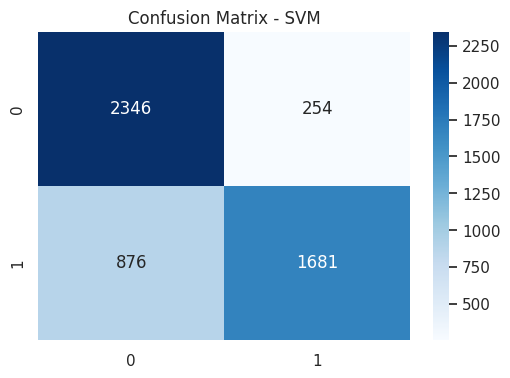

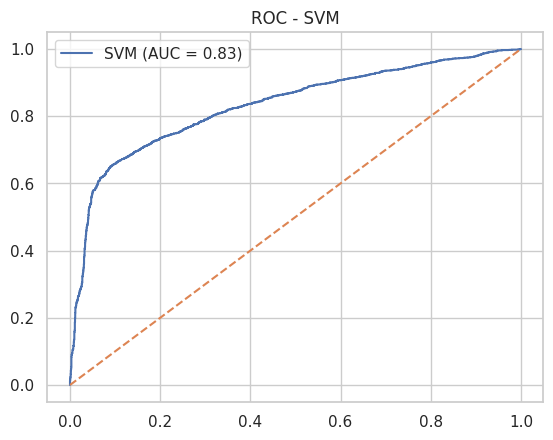

              precision    recall  f1-score   support

           0       0.73      0.90      0.81      2600
           1       0.87      0.66      0.75      2557

    accuracy                           0.78      5157
   macro avg       0.80      0.78      0.78      5157
weighted avg       0.80      0.78      0.78      5157



In [15]:
for name, res in results.items():
    print(f"\n===== Evaluation : {name} =====")

    y_pred = res['y_pred']
    y_prob = res['y_prob']
    pipeline = res['Pipeline']

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')
    plt.plot([0,1],[0,1],'--')
    plt.legend()
    plt.title(f'ROC - {name}')
    plt.show()

    print(classification_report(y_test, y_pred))